In [20]:
from __future__ import annotations

import argparse
import sys
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Get the parent directory (MHR_ENV)
parent_dir = Path().absolute().parent
if str(parent_dir) not in sys.path:
    sys.path.append(str(parent_dir))

import torch
from mhr_kit.model import faces, joint_names, joint_positions, load_mhr, model_summary, save_mesh
from mhr_kit.params import model_parameters, pose, random_identity, POSES
from mhr_kit.render import orbit_camera, render

In [2]:
device = 'cpu'
model = load_mhr(lod=1, device=device)
print(model_summary(model, lod=1))

  level of detail         1 (correctives ~664 MB in RAM)
  vertices                18,439
  triangles               36,874
  skeleton joints         127
  identity coefficients   45 (20 body + 20 head + 5 hands)
  model parameters        204 (6 rigid + joint angles + scales)
  expression coefficients 72
  pose correctives        on


In [3]:
triangles = faces(model)
triangles

array([[ 3997,  3895,  5229],
       [ 3792,  3895,  4722],
       [ 3792,  3794,  4721],
       ...,
       [18423, 18379, 18380],
       [18417, 18418, 18419],
       [18417, 18419, 18420]], shape=(36874, 3), dtype=int32)

In [4]:
# ------------------------------------------------------- one forward pass
# The average body: every identity coefficient at its mean of zero.
identity = torch.zeros(1, 45, device=device)

# `None` for the expression block is shorthand for "neutral face".
parameters = pose(model, "relaxed", device=device)

with torch.no_grad():
    vertices, skeleton_state = model(identity, parameters, None)
    
print(f"\nvertices       {tuple(vertices.shape)}  (batch, vertex, xyz in cm)")
print(f"skeleton_state {tuple(skeleton_state.shape)}  (batch, joint, [tx ty tz qx qy qz qw scale])")


vertices       (1, 18439, 3)  (batch, vertex, xyz in cm)
skeleton_state (1, 127, 8)  (batch, joint, [tx ty tz qx qy qz qw scale])


In [5]:
positions = joint_positions(skeleton_state)[0]
names = joint_names(model)
height = float(vertices[0, :, 1].max() - vertices[0, :, 1].min())
print(f"\nstature        {height:.1f} cm")
for joint in ("root", "c_head", "l_wrist", "r_wrist"):
    index = names.index(joint)
    print(f"  {joint:10s} at {positions[index].tolist()} cm")


stature        172.5 cm
  root       at [0.0, 92.39869689941406, 0.0] cm
  c_head     at [-1.5420748106730574e-14, 153.5244598388672, 4.82195520401001] cm
  l_wrist    at [21.688472747802734, 94.53114318847656, -0.11105923354625702] cm
  r_wrist    at [-21.688472747802734, 94.53114318847656, -0.11105921119451523] cm


In [6]:
labels = ["rest (T-pose)", "relaxed", "walk stride", "sitting"]
batch = torch.cat(
    [
        model_parameters(model, device=device),  # all zeros = rest pose
        pose(model, "relaxed", device=device),
        pose(model, "walk_stride", device=device),
        pose(model, "sitting", device=device),
    ]
)
started = time.perf_counter()
with torch.no_grad():
    posed, _ = model(identity, batch, None)
elapsed = time.perf_counter() - started
print(f"\nSkinned {len(labels)} poses in {elapsed * 1000:.0f} ms ({elapsed / len(labels) * 1000:.0f} ms/mesh)")

# A different body in the same pose: identity coefficients, not parameters,
# are what make someone tall, short, broad or slight.
with torch.no_grad():
    other, _ = model(random_identity(scale=1.2, seed=7, device=device), parameters, None)
other_height = float(other[0, :, 1].max() - other[0, :, 1].min())
print(f"Random identity (seed 7) is {other_height:.1f} cm tall, {other_height - height:+.1f} cm vs the mean body")



Skinned 4 poses in 90 ms (23 ms/mesh)
Random identity (seed 7) is 173.1 cm tall, +0.5 cm vs the mean body


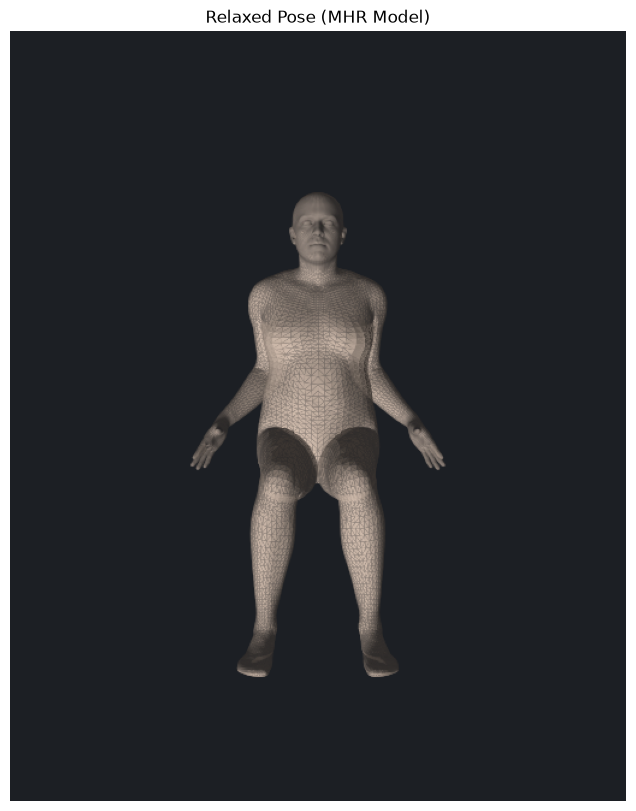

In [7]:


# 1. Grab the triangle indices from the model
triangles = faces(model)

# 2. Grab the 'relaxed' pose vertices from the batch we made earlier
# 'posed' has shape (4, 18439, 3). Index 1 is the 'relaxed' pose.
# We detach it from PyTorch gradients, move to CPU, and convert to numpy
verts_relaxed = posed[3].detach().cpu().numpy()

# 3. Set up a camera to look at the mesh
# azimuth=0 looks at the front. elevation=0 looks straight ahead.
cam = orbit_camera(verts_relaxed, azimuth=0, elevation=0, size=(512, 640))

# 4. Render the mesh into an RGB image array
image = render(verts_relaxed, triangles, cam)

# 5. Display the image in the Jupyter Notebook
plt.figure(figsize=(8, 10))
plt.imshow(image)
plt.axis('off')
plt.title("Relaxed Pose (MHR Model)")
plt.show()

In [8]:
import trimesh
import numpy as np

# Grab the relaxed pose vertices and faces
verts = posed[3].detach().cpu().numpy()
faces_np = faces(model)

# Create a trimesh object
mesh = trimesh.Trimesh(vertices=verts, faces=faces_np, process=False)

# Show it in Jupyter (creates an interactive 3D viewer)
mesh.show()

In [9]:
parameters = pose(model, "relaxed")

# Which identity coefficients affect which part of the body.
IDENTITY_GROUPS = {"body": slice(0, 20), "head": slice(20, 40), "hands": slice(40, 45)}

In [10]:
amounts = torch.linspace(-2.5, 2.5, 3)
tiles, statures, volumes = [], [], []
for amount in amounts:
    identity = torch.zeros(1, 45)
    identity[0, 0] = amount
    with torch.no_grad():
        vertices, _ = model(identity, parameters, None)
    mesh = vertices[0].numpy()
    statures.append(float(mesh[:, 1].max() - mesh[:, 1].min()))
    volumes.append(trimesh.Trimesh(mesh, triangles, process=False).volume / 1000.0)  # cm^3 -> litres
    # One camera for the whole sweep, so size differences stay comparable.
    camera = orbit_camera(mesh, azimuth=20.0, size=(190, 340), center=[0.0, 86.0, 0.0], radius=100.0)
    tiles.append(render(mesh, triangles, camera))
print(f"\nSweeping identity coefficient {0} from {amounts[0]:+.1f} to {amounts[-1]:+.1f}:")
print("  stature (cm):", " ".join(f"{value:5.0f}" for value in statures))
print("  volume  (l): ", " ".join(f"{value:5.0f}" for value in volumes))


Sweeping identity coefficient 0 from -2.5 to +2.5:
  stature (cm):   173   173   173
  volume  (l):     45    82   133


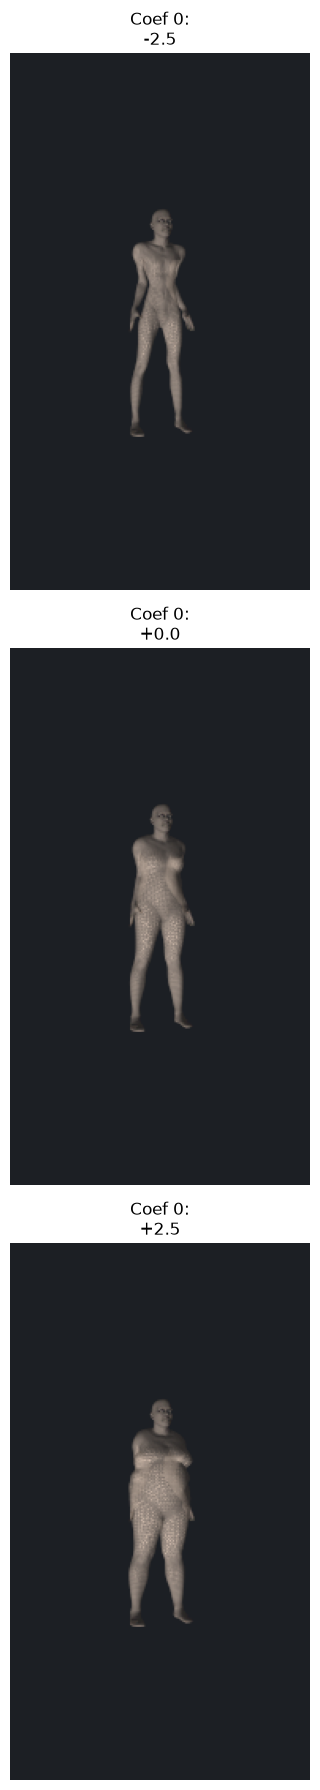

In [11]:
fig, axes = plt.subplots(len(tiles), 1, figsize=(4, 6 * len(tiles)))

for ax, image, amount in zip(axes, tiles, amounts):
    ax.imshow(image)
    ax.set_title(f"Coef 0:\n{amount:+.1f}", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

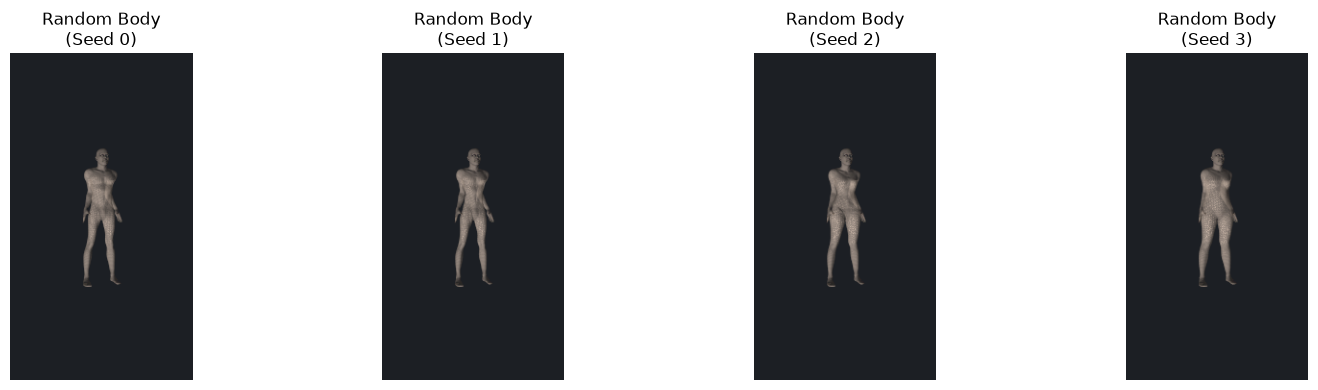

In [12]:
tiles = []
for seed in range(4):
    identity = random_identity(scale=1.4, groups=("body",), seed=seed)
    with torch.no_grad():
        vertices, _ = model(identity, parameters, None)
    mesh = vertices[0].numpy()
    camera = orbit_camera(mesh, azimuth=20.0, size=(190, 340), center=[0.0, 86.0, 0.0], radius=100.0)
    tiles.append(render(mesh, triangles, camera))


fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, image, seed in zip(axes, tiles, range(4)):
    ax.imshow(image)
    ax.set_title(f"Random Body\n(Seed {seed})")
    ax.axis('off')

plt.tight_layout()
plt.show()

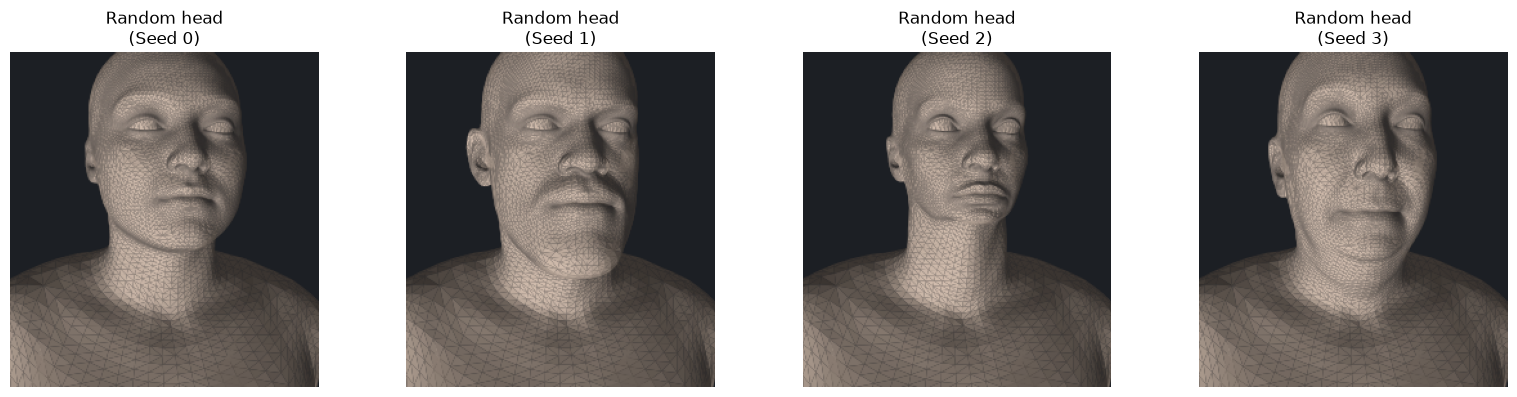

In [14]:
head_index = joint_names(model).index("c_head")
tiles = []
for seed in range(4):
    identity = random_identity(scale=1.6, groups=("head",), seed=100 + seed)
    with torch.no_grad():
        vertices, skeleton = model(identity, parameters, None)
    mesh = vertices[0].numpy()
    head = joint_positions(skeleton)[0, head_index].numpy()
    # Zoom in: a 14 cm radius around the head joint fills the frame with a face.
    camera = orbit_camera(mesh, azimuth=12.0, size=(240, 260), center=head, radius=14.0)
    tiles.append(render(mesh, triangles, camera))



fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, image, seed in zip(axes, tiles, range(4)):
    ax.imshow(image)
    ax.set_title(f"Random head\n(Seed {seed})")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [15]:
identity

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.8128, -2.3948,  2.2618,  1.4245,
          0.6720,  1.3173, -1.0159,  0.7065,  0.8130, -1.0868,  0.6547, -3.5913,
          2.6025, -3.1120, -2.1158,  0.8003, -1.7246, -0.7551, -0.0770, -1.7737,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000]])

In [16]:
# ------------------------------------------------------ expression basis
# Each of the 72 coefficients is one facial blendshape; driving them one at a
# time shows what the basis contains (jaw, brows, eyelids, mouth shapes, ...).
identity = torch.zeros(1, 45)
tiles = []
shown = [0, 1, 2, 3, 8, 12, 16, 24, 32, 40, 48, 60]
for coefficient in shown:
    expression = torch.zeros(1, 72)
    expression[0, coefficient] = 1.0
    with torch.no_grad():
        vertices, skeleton = model(identity, parameters, expression)
    mesh = vertices[0].numpy()
    head = joint_positions(skeleton)[0, head_index].numpy()
    camera = orbit_camera(mesh, azimuth=8.0, size=(200, 220), center=head, radius=13.0)
    tiles.append(render(mesh, triangles, camera))
print(f"Rendered expression blendshapes {shown}")

Rendered expression blendshapes [0, 1, 2, 3, 8, 12, 16, 24, 32, 40, 48, 60]


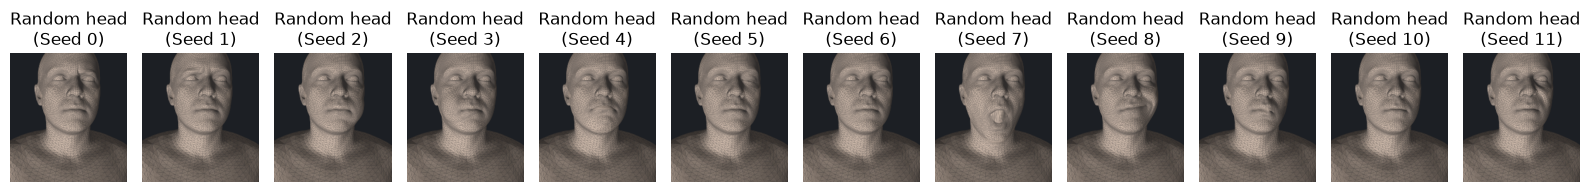

In [ ]:
fig, axes = plt.subplots(1, len(tiles), figsize=(16, len(tiles)))

for ax, image, seed in zip(axes, tiles, range(len(tiles))):
    ax.imshow(image)
    ax.set_title(f"Random head\n(Seed {seed})")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [24]:
model = load_mhr(lod=1)
triangles = faces(model)
identity = torch.zeros(1, 45)

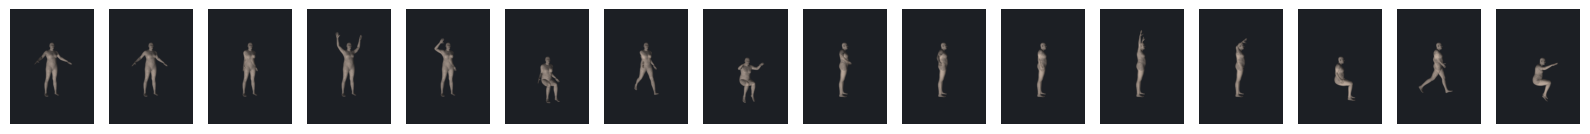

In [ ]:
names = list(POSES)
batch = torch.cat([pose(model, name) for name in names])
with torch.no_grad():
    vertices, _ = model(identity, batch, None)
meshes = vertices.numpy()

tiles = []
for azimuth in (25.0, 85.0):  # Instead of just looking at the bodies from the front, it loops over two camera angles
    camera = orbit_camera(meshes, azimuth=azimuth, size=(220, 300))
    tiles += [render(mesh, triangles, camera) for mesh in meshes]

fig, axes = plt.subplots(1, len(tiles), figsize=(16, len(tiles)))

for ax, image, seed in zip(axes, tiles, range(len(tiles))):
    ax.imshow(image)
    ax.axis('off')

plt.tight_layout()
plt.show()

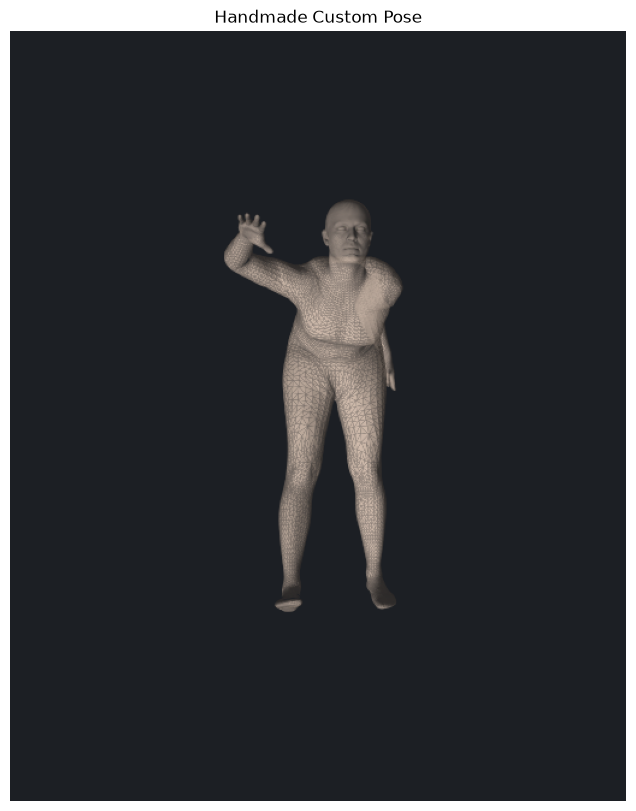

In [36]:
# 1. Get the triangle indices from the model
triangles = faces(model)

# 2. Create the average identity (zeros)
identity = torch.zeros(1, 45, device=device)


# ------------------------------------------------------ a pose, by name
# Anything not named stays at its rest value, so a readable dict is enough.
handmade = model_parameters(
    model,
    {
        "root_ry": 0.1,  # turn the whole body 20 degrees to its left
        "spine_bend0": 1.70,  # lean forward from the lower spine
        "neck_bend": -0.95,  # look up
        "r_uparm_ry": 1.00,  # right arm out and up
        "r_uparm_rz": 1.20,
        "r_elbow_bend": 0.60,
        "l_uparm_ry": -0.65,  # left arm hanging
        "l_uparm_rz": -0.85,
        "l_elbow_bend": 0.30,
        "r_upleg_rz": -0.30,  # right leg a step forward
        "l_knee_bend": 0.20,
    },
)

# 3. Run the forward pass with your custom 'handmade' parameters
with torch.no_grad():
    vertices, _ = model(identity, handmade, None)

# 4. Convert the vertices to a numpy array for the renderer
mesh = vertices[0].numpy()

# 5. Set up a camera to look at the mesh
# Using azimuth=15 to get a slight 3/4 front view so we can see the turned body and raised arm
camera = orbit_camera(mesh, azimuth=0.0, elevation=0.0, size=(512, 640))

# 6. Render the mesh into an image
image = render(mesh, triangles, camera)

# 7. Display the image in Jupyter
plt.figure(figsize=(8, 10))
plt.imshow(image)
plt.axis('off')
plt.title("Handmade Custom Pose")
plt.show()